In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression , SGDRegressor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

In [2]:
X = 6 * np.random.rand(200, 1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200, 1)

# y = 0.8x^2 + 0.9x + 2

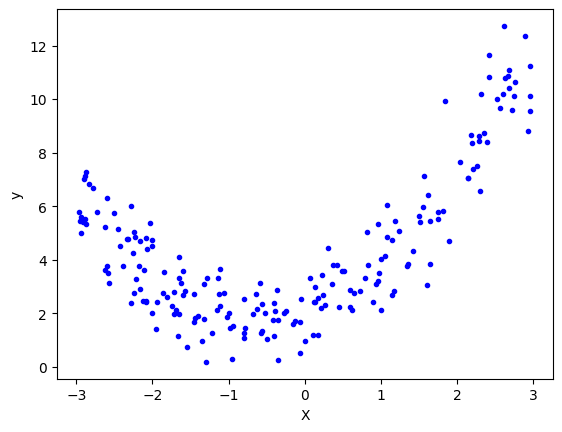

In [3]:
plt.plot(X, y,'b.')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

In [4]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# Apply Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
r2_score(y_test, y_pred)

0.12838871045024947

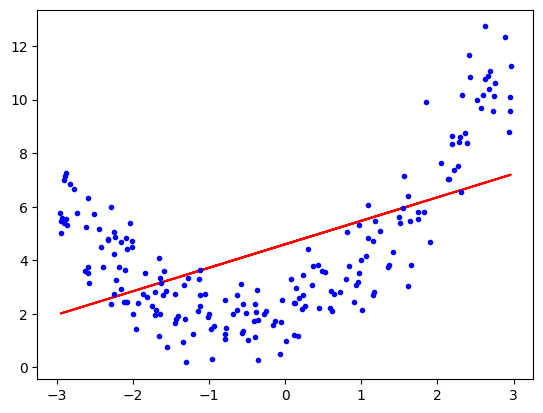

In [6]:
plt.plot(X_train, lr.predict(X_train), 'r-')
plt.plot(X, y, 'b.')

In [7]:
# Apply Polynomical Regression
# Degree 2D
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.fit_transform(X_test)

In [8]:
print(X_train_poly.shape)
print(X_test_poly.shape)

(160, 3)
(40, 3)


In [9]:
lr = LinearRegression()
lr.fit(X_train_poly, y_train)
y_pred = lr.predict(X_test_poly)
r2_score(y_test, y_pred)

0.8404140121943304

In [10]:
# Coefficient
lr.coef_

array([[0.        , 0.9458625 , 0.77989548]])

In [11]:
# intercept
lr.intercept_

array([2.07746919])

In [18]:
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

In [19]:
# Underfitting

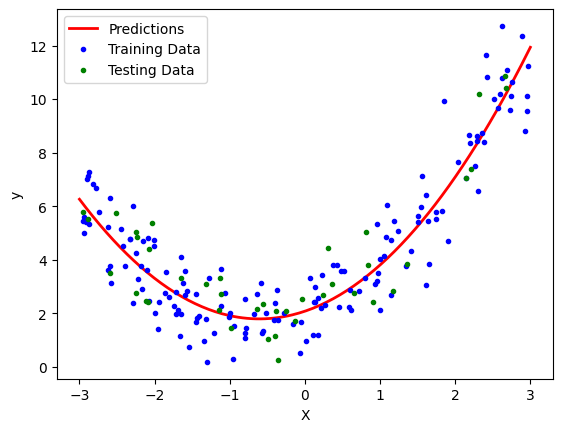

In [20]:
plt.plot(X_new, y_new, 'r-', linewidth=2, label='Predictions')
plt.plot(X_train, y_train, 'b.', label='Training Data')
plt.plot(X_test, y_test, 'g.', label='Testing Data')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

In [21]:
# Polynomical Function for any degree

In [22]:
def polynomial_regression(degree):
  X_new = np.linspace(-3, 3, 100).reshape(100, 1)
  polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
  X_new_poly = poly.fit_transform(X_new)

  std_scaler = StandardScaler()
  lr = LinearRegression()
  polynomial_regression = Pipeline([
      ('poly_features', polybig_features),
      ('std_scaler', std_scaler),
      ('lr', lr)
  ])
  polynomial_regression.fit(X, y)
  y_newbig = polynomial_regression.predict(X_new)
  plt.plot(X_new, y_newbig, 'r-', label='degree {}'.format(degree), linewidth=2)
  plt.plot(X_train, y_train, 'b.', linewidth=3)
  plt.plot(X_test, y_test, 'g.', linewidth=3)
  plt.xlabel('X')
  plt.ylabel('y')
  plt.legend()
  plt.axis([-3, 3, 0, 10])
  plt.show()

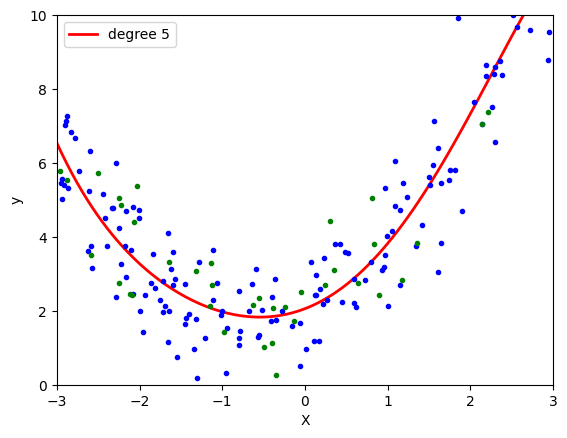

In [23]:
polynomial_regression(5)

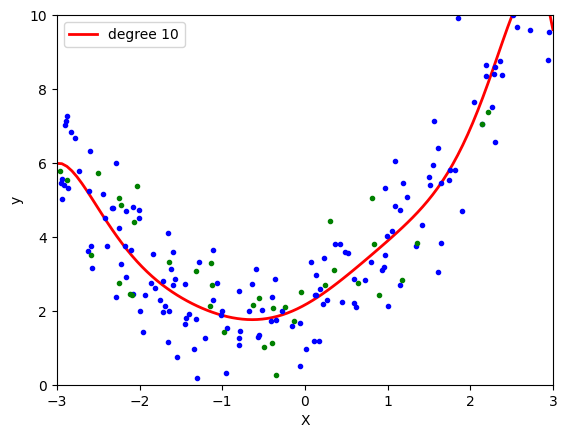

In [24]:
polynomial_regression(10)

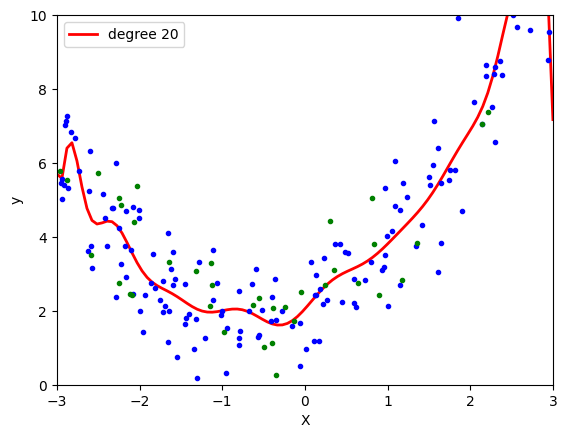

In [25]:
polynomial_regression(20)

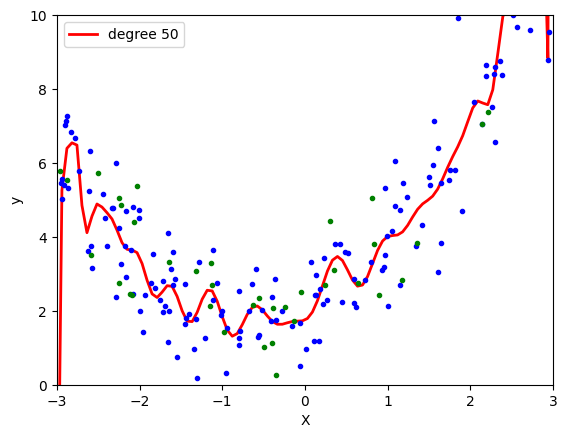

In [26]:
# Overfitting
polynomial_regression(50)

In [27]:
# 3D Polynomial Regression
x = 7 * np.random.rand(100, 1) - 2.8
y = 7 * np.random.rand(100, 1) - 2.8

z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y + 2 + np.random.randn(100, 1)
# z = x^2 + y^2 + 0.2x + 0.2y + 0.1xy + 2

In [28]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.show()

In [29]:
# Apply Linear Regression for 3D
lr = LinearRegression()
lr.fit(np.array([x,y]).reshape(100,2),z)

x_input = np.linspace(x.min(), x.max(), 10)
y_input = np.linspace(y.min(), y.max(), 10)
xGrid, yGrid = np.meshgrid(x_input, y_input)

final = np.vstack((xGrid.ravel().reshape(1,100), yGrid.ravel().reshape(1,100))).T
z_final = lr.predict(final).reshape(10,10)

In [30]:
import plotly.graph_objects as go
fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.add_trace(go.Surface(x=x_input, y=y_input, z=z_final))
fig.show()

In [31]:
# Apply Polynomial Regression for 3D
X_multi = np.array([x,y]).reshape(100,2)
X_multi.shape

(100, 2)

In [32]:
poly = PolynomialFeatures(degree=2, include_bias=False) # for degree 2
X_multi_poly = poly.fit_transform(X_multi)
X_test_poly = poly.transform(final)

In [33]:
print('Input', poly.n_features_in_)
print('Output', poly.n_output_features_)
print('Power combination\n',poly.powers_)

Input 2
Output 5
Power combination
 [[1 0]
 [0 1]
 [2 0]
 [1 1]
 [0 2]]


In [34]:
X_multi_poly.shape

(100, 5)

In [35]:
lr = LinearRegression()
lr.fit(X_multi_poly, z)
z_final = lr.predict(X_multi_poly).reshape(10,10)

In [36]:
fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.add_trace(go.Surface(x=x_input, y=y_input, z=z_final))
fig.update_layout(scene = dict(zaxis = dict(range=[0,35])))
fig.show()